In [1]:
import sys
import os

repo_root = "/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import psp

# Reload the package
import sys
# Remove the main package if it's in sys.modules
if 'psp' in sys.modules:
    del sys.modules['psp']

# Remove any submodules of psp
for mod in list(sys.modules.keys()):
    if mod.startswith('psp.'):
        del sys.modules[mod]
import psp

import scperturb as scp
adata = psp.utils.read_anndata("/tscc/projects/ps-malilab/ydoctor/CM4AI/KOLF_Chromatin_Modifiers/iPSC/adata_files/KOLF_Chromatin_Modifiers_Knockdown_Evaluated.h5ad")
adata.obs['perturbation'] = [gRNA if "NTC" not in gRNA else "NTC" for gRNA in adata.obs['gRNA']]

/tscc/nfs/home/ydoctor/miniconda3/envs/perturb_seq_env/lib/python3.11/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML


Preprocessing data for edist calculation...
filtered out 2831 genes that are detected in less than 3 cells
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)


/tscc/nfs/home/ydoctor/miniconda3/envs/perturb_seq_env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.


computing PCA
    with n_comps=50
    finished (0:00:17)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])
computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 50
    computed neighbors (0:00:03)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
Processing with 10 NTC cells...


100%|██████████| 331/331 [00:00<00:00, 714.53it/s]


Processing with 25 NTC cells...


...

100%|██████████| 331/331 [00:01<00:00, 303.95it/s]


Processing with 3200 NTC cells...


100%|██████████| 331/331 [00:01<00:00, 188.96it/s]


Processing with 4839 NTC cells...


100%|██████████| 331/331 [00:02<00:00, 129.39it/s]


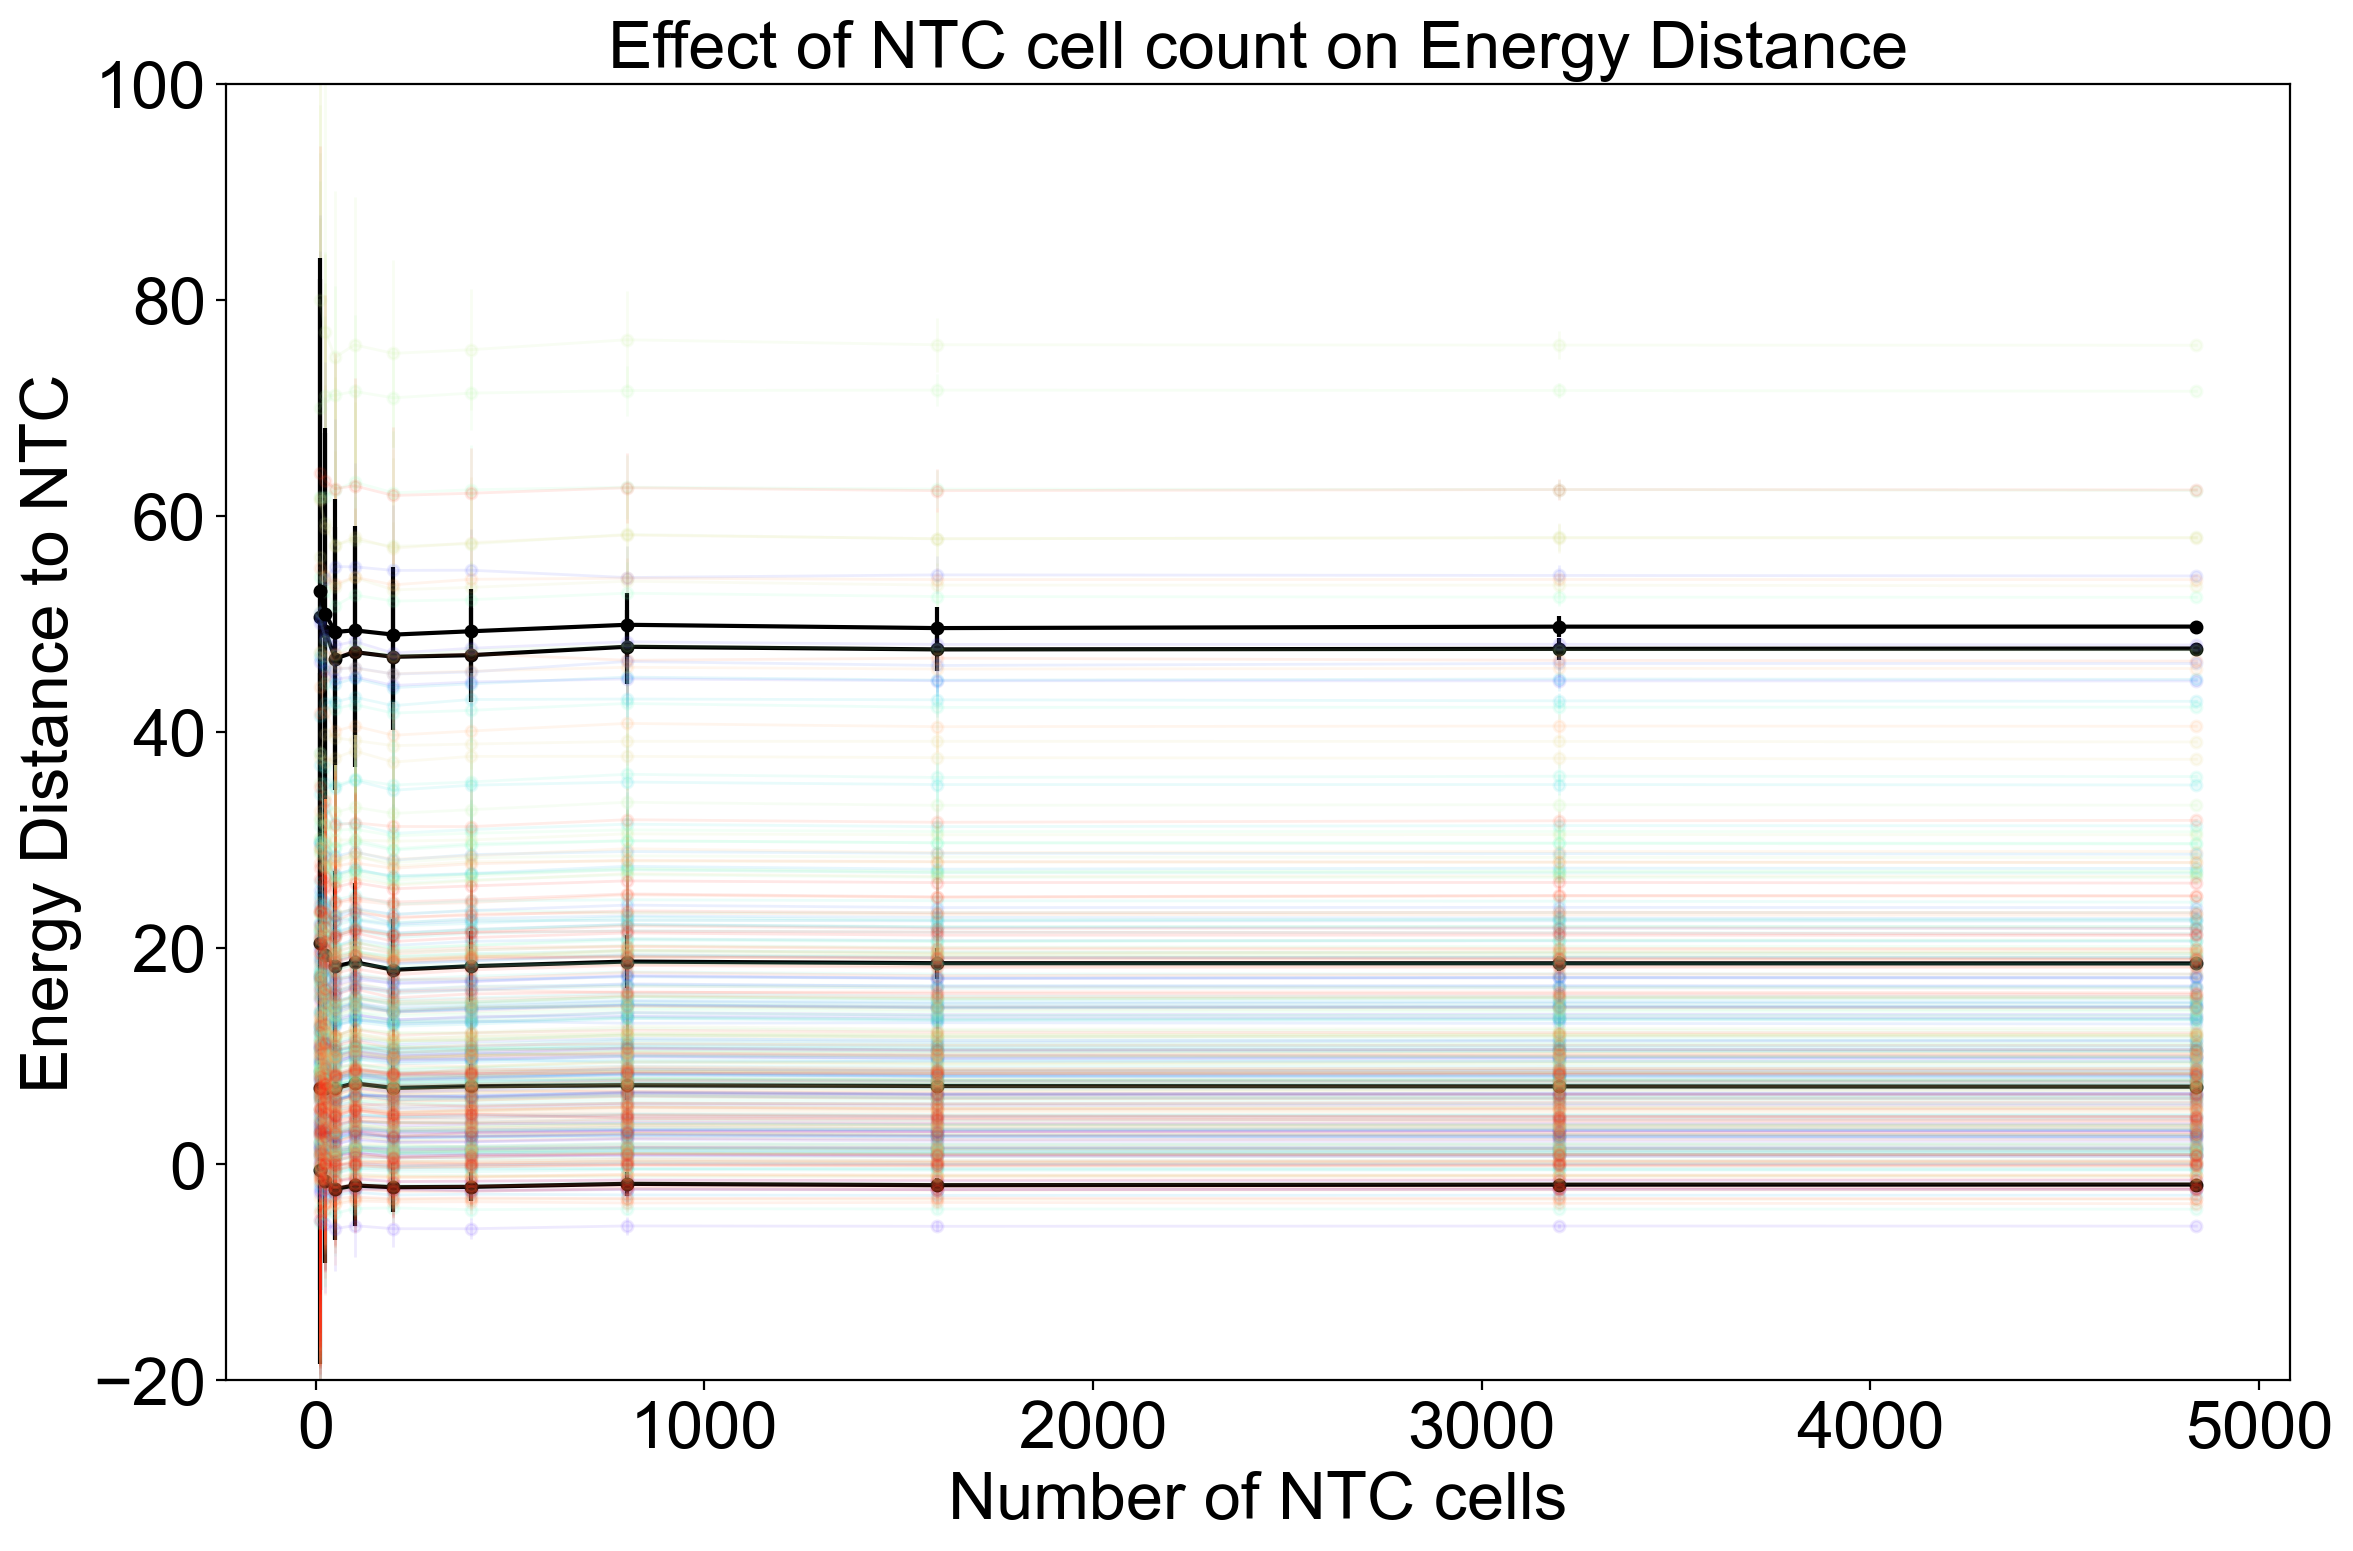

In [182]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import scperturb as scp
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import squareform, pdist
from tqdm_joblib import tqdm_joblib
from scipy.stats import spearmanr
from joblib import Parallel, delayed
from joblib import parallel_backend
import pandas as pd
from warnings import warn
from tqdm.contrib.concurrent import process_map
import time

def preprocess_for_edist(adata):
    adata_edist = adata.copy()
    adata_edist.X = adata_edist.layers['counts'].copy()
    sc.pp.filter_genes(adata_edist, min_cells=3)
    n_var_max = 2000
    sc.pp.highly_variable_genes(adata_edist, n_top_genes=n_var_max, flavor='seurat_v3', subset=False, layer='counts')
    sc.pp.normalize_total(adata_edist, inplace=True)
    sc.pp.log1p(adata_edist)
    sc.pp.scale(adata_edist)
    sc.pp.pca(adata_edist, n_comps=50, use_highly_variable=True)
    sc.pp.neighbors(adata_edist)
    return adata_edist

def subsample_adata(adata, num_ntc_cells, random_seed=42):
    np.random.seed(random_seed)
    ntc_cells = adata[adata.obs['perturbed'] == "False"].obs.index
    subsampled_ntc_cells = np.random.choice(ntc_cells, size=(len(ntc_cells) - num_ntc_cells), replace=False)
    adata_subsampled = adata[~adata.obs.index.isin(subsampled_ntc_cells)]
    return adata_subsampled

def edist_computation(adata, obs_key='perturbation', obsm_key='X_pca', pwd=None, 
          dist='sqeuclidean', sample_correct=True, n_jobs=1, verbose=True, control=None):
    if control is not None:
        return edist_to_control(adata, obs_key=obs_key, control=control, obsm_key=obsm_key,
                               dist=dist, sample_correct=sample_correct, n_jobs=n_jobs, verbose=verbose)
    else:
        pwd = pairwise_pca_distances(adata, obs_key=obs_key, obsm_key=obsm_key, 
                                    dist=dist, sample_correct=sample_correct, 
                                    n_jobs=n_jobs, verbose=verbose) if pwd is None else pwd
        sigmas = np.diag(pwd)
        deltas = pwd
        estats = 2 * deltas - sigmas - sigmas[:, np.newaxis]
        return estats

def edist_to_control(adata, obs_key='perturbation', control='NTC', obsm_key='X_pca',
                    dist='sqeuclidean', sample_correct=True, n_jobs=-1, verbose=False):
    import pandas as pd
    import numpy as np
    import scanpy as sc
    from tqdm import tqdm
    from sklearn.metrics import pairwise_distances
    from joblib import Parallel, delayed
    from warnings import warn
    
    if obsm_key=='X_pca' and 'X_pca' not in adata.obsm.keys():
        warn('PCA embedding not found, computing...')
        sc.pp.pca(adata)
    
    X = adata.obsm[obsm_key].copy()
    y = adata.obs[obs_key].astype(str).copy()
    groups = pd.unique(y)
    
    if control not in groups:
        raise ValueError(f"Control '{control}' not found in {obs_key}")
    
    control_X = X[y==control].copy()
    control_pwd = pairwise_distances(control_X, metric=dist)
    N = len(control_X)
    M = N-1 if sample_correct else N
    sigma_control = np.sum(control_pwd) / (N * M)
    
    def compute_group_to_control(group):
        if group == control:
            return (group, 0.0)
        group_X = X[y==group].copy()
        between_pwd = pairwise_distances(group_X, control_X, metric=dist)
        delta = np.mean(between_pwd)
        if len(group_X) > 1:
            group_pwd = pairwise_distances(group_X, metric=dist)
            N_group = len(group_X)
            M_group = N_group-1 if sample_correct else N_group
            sigma_group = np.sum(group_pwd) / (N_group * M_group)
        else:
            sigma_group = 0
        edist_val = 2 * delta - sigma_group - sigma_control
        return (group, edist_val)
    
    fct = tqdm if verbose else lambda x: x
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_group_to_control)(group) for group in fct(groups)
    )
    
    df = pd.DataFrame(index=groups, columns=[control], dtype=float)
    for group, dist_val in results:
        df.loc[group, control] = dist_val

    df = df.rename(columns={control: 'edist'})
    df.index.name = obs_key
    df.name = f'energy distance to {control}'
    
    return df

import pandas as pd
import numpy as np
import scanpy as sc

from tqdm import tqdm
from sklearn.metrics import pairwise_distances
from itertools import combinations
from joblib import Parallel, delayed
from warnings import warn

def pairwise_pca_distances(adata, obs_key, obsm_key='X_pca', dist='sqeuclidean',
                           sample_correct=True, n_jobs=-1, verbose=True):
    if obsm_key=='X_pca' and 'X_pca' not in adata.obsm.keys():
        warn('PCA embedding not found, computing...')
        sc.pp.pca(adata)
    
    X = adata.obsm[obsm_key].copy()
    y = adata.obs[obs_key].astype(str).copy()
    groups = pd.unique(y)
    df = pd.DataFrame(index=groups, columns=groups, dtype=float)
    fct = tqdm if verbose else lambda x: x
    combis = list(combinations(groups, 2)) + [(x,x) for x in groups]
    def one_step(pair):
        p1, p2 = pair
        x1 = X[y==p1].copy()
        N = len(x1)
        x2 = X[y==p2].copy()
        pwd = pairwise_distances(x1, x2, metric=dist)
        M = len(x2)-1 if (p1==p2) & sample_correct else len(x2)
        factor = N * M
        mean_pwd = np.sum(pwd) / factor
        return (p1, p2, mean_pwd)
    res = Parallel(n_jobs=n_jobs)(delayed(one_step)(pair) for pair in fct(combis))
    for p1, p2, val in res:
        df.loc[p1, p2] = val
        df.loc[p2, p1] = val
    df.index.name = obs_key
    df.columns.name = obs_key
    df.name = 'pairwise PCA distances'
    return df

# Preprocess the data for edist calculation
adata = psp.utils.read_anndata("/tscc/projects/ps-malilab/ydoctor/CM4AI/KOLF_Chromatin_Modifiers/iPSC/adata_files/KOLF_Chromatin_Modifiers_Knockdown_Evaluated.h5ad")
adata.obs['perturbation'] = [gRNA if "NTC" not in gRNA else "NTC" for gRNA in adata.obs['gRNA']]
print("Preprocessing data for edist calculation...")
adata_edist = preprocess_for_edist(adata)

# Define the number of NTC cells to subsample
num_ntc_cells = len(adata[adata.obs['perturbed'] == "False"].obs.index) 
ntc_cell_counts = [10, 25, 50, 100, 200, 400, 800, 1600, 3200, num_ntc_cells]
n_seeds = 100

# Initialize dictionary to store results
edist_results = {}

# Loop through each NTC count
for ntc_count in ntc_cell_counts:
    print(f"Processing with {ntc_count} NTC cells...")
    edist_values = {}
    runtimes = []

    # Run multiple seeds for each NTC count
    for seed in range(n_seeds):
        # Record runtime per seed
        t0 = time.time()

        # Subsample the data
        adata_subsampled = subsample_adata(adata_edist, ntc_count, random_seed=seed)
        
        # Compute edist to control directly without using parallel processing
        edist_df = edist_computation(adata_subsampled, obs_key='perturbation', 
                                        control='NTC', obsm_key='X_pca', dist='sqeuclidean')
        
        # Store results for each perturbation
        for pert, edist in zip(edist_df.index, edist_df['edist']):
            if pert not in edist_values:
                edist_values[pert] = []
            edist_values[pert].append(edist)

        t1 = time.time()
        runtimes.append(t1 - t0)

    # Calculate mean and standard deviation for each perturbation,
    # and store runtimes and mean runtime for this ntc_count
    for pert in edist_values:
        if pert not in edist_results:
            edist_results[pert] = {
                'values': [],
                'mean': [],
                'median': [],
                'std': [],
                'ntc_counts': [],
                'runtimes': [],
                'mean_runtime': []
            }
        
        edist_results[pert]['values'].append(edist_values[pert])
        edist_results[pert]['mean'].append(np.mean(edist_values[pert]))
        edist_results[pert]['median'].append(np.median(edist_values[pert]))
        edist_results[pert]['std'].append(np.std(edist_values[pert]))
        edist_results[pert]['ntc_counts'].append(ntc_count)
        edist_results[pert]['runtimes'].append(runtimes)
        edist_results[pert]['mean_runtime'].append(np.mean(runtimes))

# Plot the results
plt.figure(figsize=(12, 8))

# Get unique colors for each perturbation
perturbations = list(edist_results.keys())
colors = plt.cm.rainbow(np.linspace(0, 1, len(perturbations)))

# Select 5 random perturbations to highlight
import random
random.seed(42)  # For reproducibility
highlighted_perts = random.sample(perturbations, 5)

# Plot each perturbation
for i, pert in enumerate(perturbations):
    means = (edist_results[pert]['mean'])
    stds = (edist_results[pert]['std'])
    ntc_counts = edist_results[pert]['ntc_counts']
    
    # Set alpha and color based on whether this is a highlighted perturbation
    if pert in highlighted_perts:
        plt.errorbar(ntc_counts, means, yerr=stds, fmt='-o', 
                     color='black', alpha=1.0, label=pert, 
                     markersize=4, linewidth=1.5)
    else:
        plt.errorbar(ntc_counts, means, yerr=stds, fmt='-o', 
                     color=colors[i], alpha=0.1, label=pert, 
                     markersize=4, linewidth=1.0)

plt.rcParams.update({'font.family': 'Arial'})
plt.xlabel('Number of NTC cells', fontsize=24)
plt.ylabel('Energy Distance to NTC', fontsize=24)
plt.title('Effect of NTC cell count on Energy Distance', fontsize=24)
plt.grid(False)
plt.ylim(-20,100)

plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

# Add legend outside the plot (optional: increase font size if legend is used)
# plt.legend(fontsize=24)  # Uncomment if you want to show the legend

plt.tight_layout()
plt.show()

In [185]:
pct_errors = {i:[] for i in ntc_cell_counts}
for pert in edist_results:
    true_value = edist_results[pert]['median'][-1]
    for i,values in enumerate(edist_results[pert]['median']):
        percent_error = 100*(abs(np.median(values)-true_value)/((true_value)+1e-6))
        pct_errors[ntc_cell_counts[i]].append(percent_error)

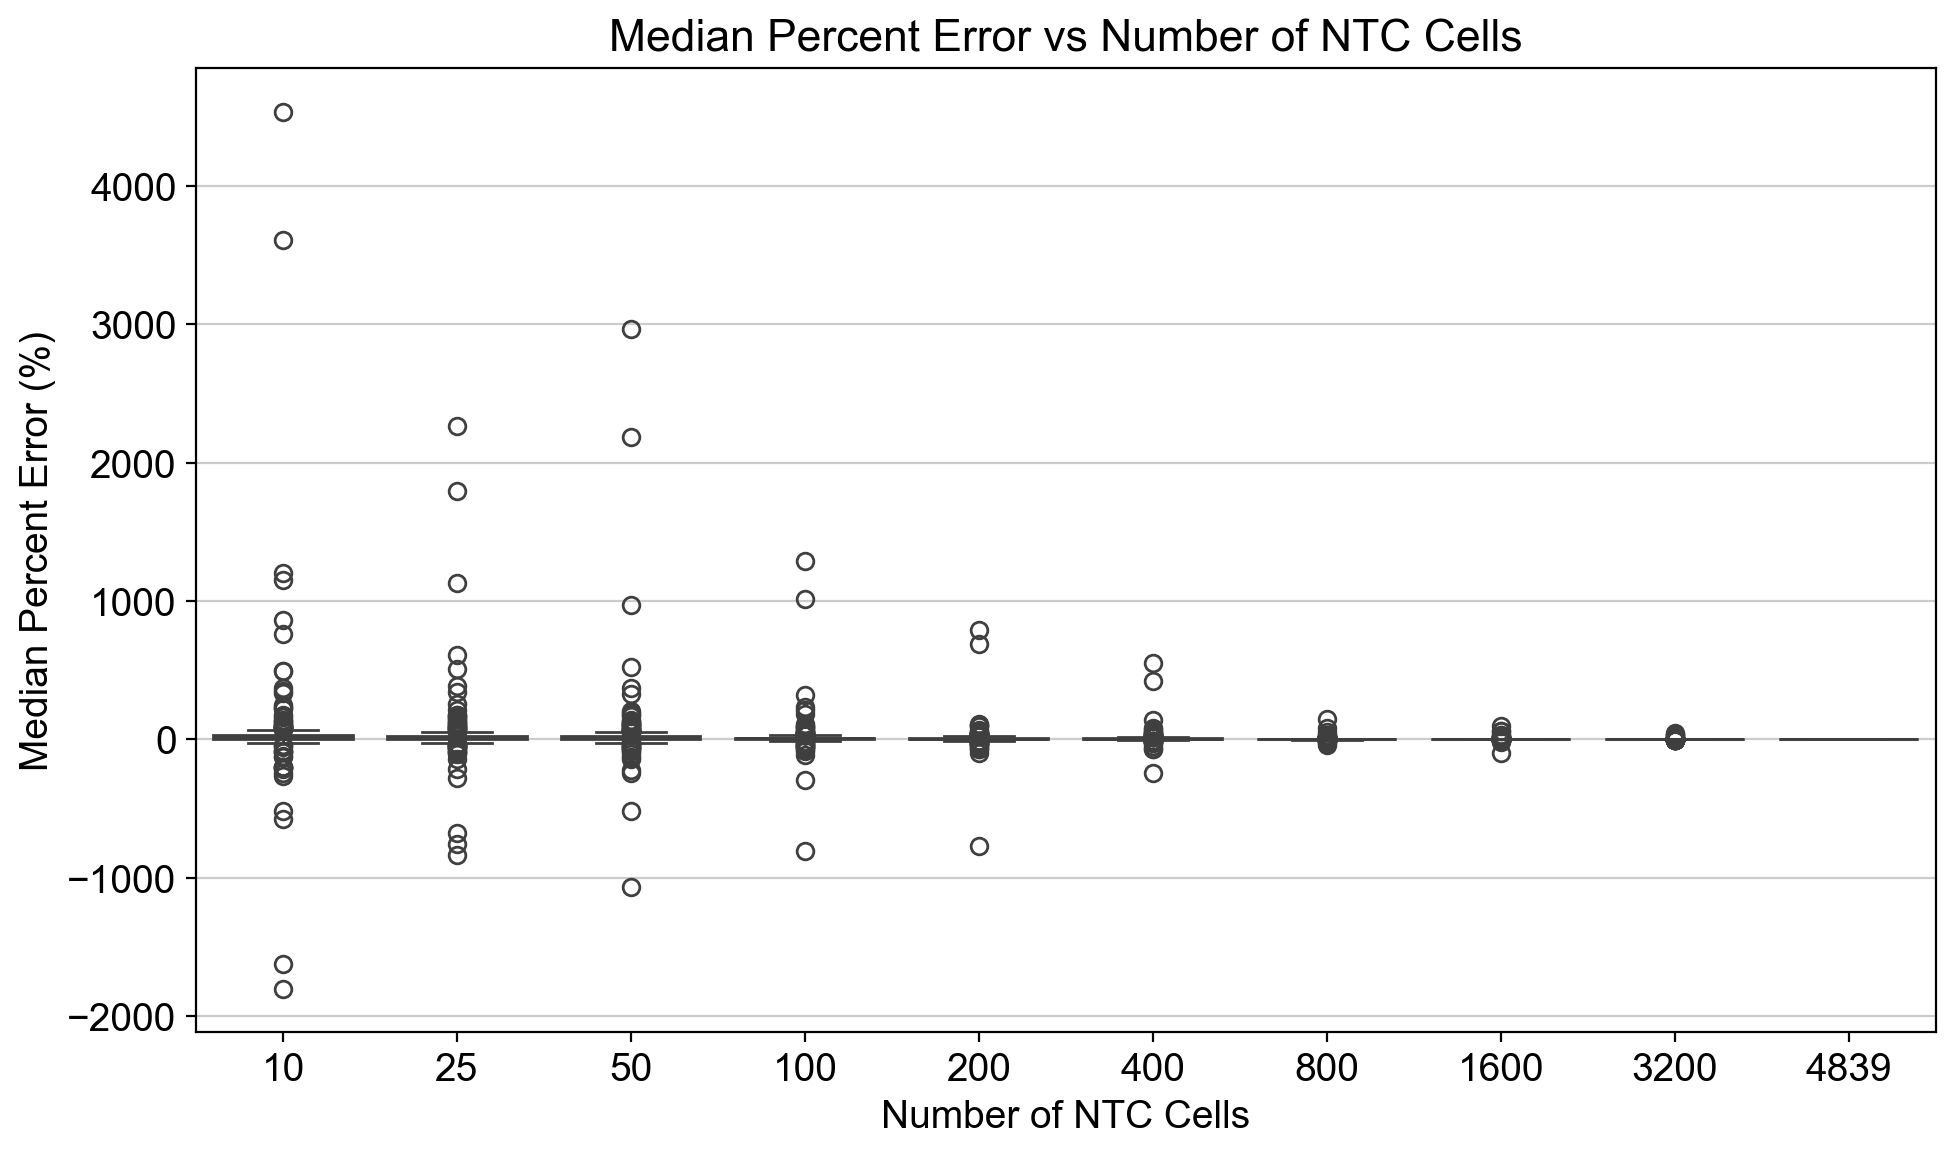

,10,25,50,100,200,400,800,1600,3200,4839
0,27.381942,42.358743,40.408066,27.787066,16.926437,9.375221,6.081401,5.344994,1.777422,0.0
1,80.078418,13.278337,25.609357,3.149238,11.904838,1.736555,0.180262,1.563441,1.353853,0.0
2,247.260736,145.341911,102.346563,1.831089,10.307901,2.993843,4.239354,4.600023,0.500600,0.0
3,7.935897,1.676428,23.214710,2.664896,6.991400,3.182143,0.756868,0.353932,0.303558,0.0
4,0.574229,35.536511,38.702164,14.929684,12.099324,8.525222,0.183521,2.084802,1.317276,0.0
...,...,...,...,...,...,...,...,...,...,...
326,50.942454,7.777821,2.005454,3.916544,0.629921,4.096934,2.137290,0.672657,0.317452,0.0
327,4.112552,0.402054,4.237354,3.072327,2.811116,2.438464,0.364273,0.704420,0.197655,0.0
328,23.455972,49.513429,42.869719,4.903067,31.880020,7.365359,0.488317,0.979796,0.526762,0.0
329,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


In [186]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert pct_errors to a DataFrame
pct_errors_df = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in pct_errors.items()]))

# Melt dataframe for easier plotting
pct_errors_long = pct_errors_df.melt(var_name="NTC cells", value_name="Median Percent Error")

# Boxplot of percent error vs NTC cells
plt.figure(figsize=(10, 6))
sns.boxplot(x="NTC cells", y="Median Percent Error", data=pct_errors_long)
plt.xlabel('Number of NTC Cells', fontsize=14)
plt.ylabel('Median Percent Error (%)', fontsize=14)
plt.title('Median Percent Error vs Number of NTC Cells', fontsize=16)
plt.tight_layout()
plt.show()

pct_errors_df  # (optional: show the dataframe as output)

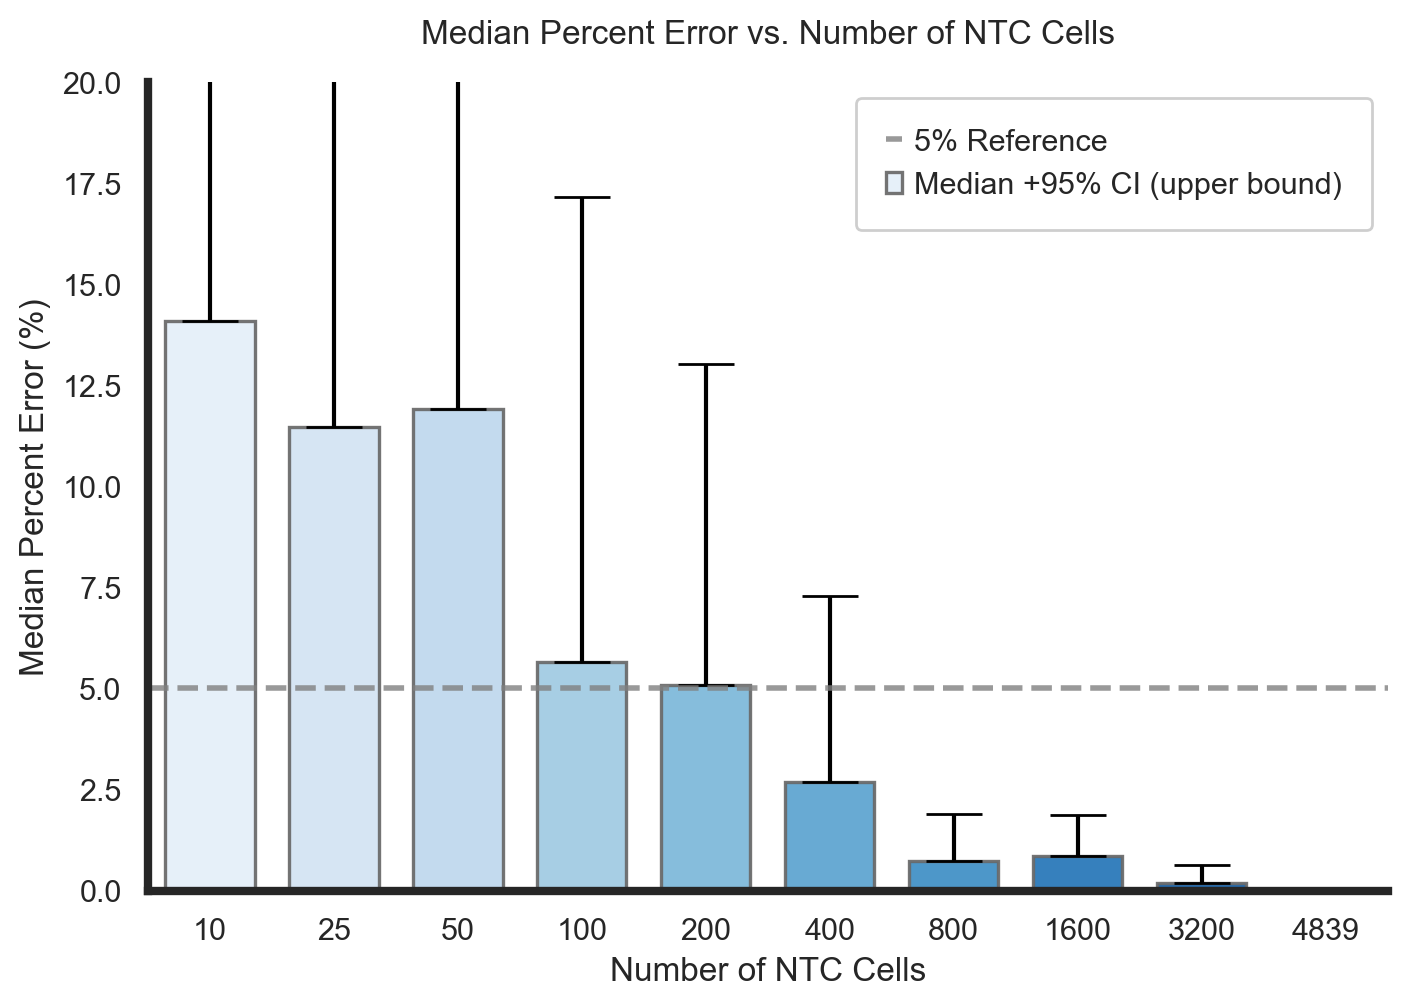

In [220]:
# Bar plot of the median percent error as a function of number of NTC cells, publication-quality version

import numpy as np
import scipy.stats as stats
import matplotlib as mpl
import seaborn as sns

# Set global styles for publication-quality
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans", "sans-serif"],
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 17,
    "axes.linewidth": 3,  # Thicker axes line
    "lines.linewidth": 2,
})

sns.set_context("notebook")
sns.set_style("white")

# Prepare error bar data
mean_pct_error = pct_errors_df.median(axis=0)
n_per_group = pct_errors_df.count(axis=0)
stderr = pct_errors_df.std(axis=0, ddof=1) / np.sqrt(n_per_group)
ci95 = 1.96 * stderr  # 95% CI, normal approx

yerr = np.vstack([np.zeros_like(ci95.values), ci95.values])
ntc_numbers = mean_pct_error.index.astype(int)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

bar_colors = sns.color_palette("Blues", n_colors=len(ntc_numbers))
bars = ax.bar(
    range(len(ntc_numbers)),
    mean_pct_error.values,
    yerr=yerr,
    align='center',
    alpha=0.93,
    capsize=10,
    color=bar_colors,
    edgecolor='dimgray',
    linewidth=1.2,
    width=0.72,
    label='Median +95% CI (upper bound)'
)

# Turn off the grid
ax.grid(False)

# Make x/y axes thicker and remove top/right box ("spines")
for s in ['bottom', 'left']:
    ax.spines[s].set_linewidth(3)
for s in ['right', 'top']:
    ax.spines[s].set_visible(False)

# Axis labels and title
ax.set_xlabel('Number of NTC Cells')
ax.set_ylabel('Median Percent Error (%)')
ax.set_title('Median Percent Error vs. Number of NTC Cells', pad=14)


# Custom X-axis ticks and limits
ax.set_xticks(range(len(ntc_numbers)))
ax.set_xticklabels(ntc_numbers, rotation=0)
ax.set_ylim(0, 20)
ax.set_xlim(-0.5, len(ntc_numbers)-0.5)

ax.axhline(5, linestyle='--', color='gray', linewidth=2, alpha=0.8, label='5% Reference')


# Elegant legend outside upper right
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='best', frameon=True, framealpha=0.95, borderpad=1)

fig.tight_layout(pad=2)
fig.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/median_percent_error_vs_ntc_cells.svg', dpi=300)
plt.show()

In [196]:
std_pct_error

10      371.088672
25      196.065218
50      225.201238
100     106.794625
200      73.591673
400      42.712010
800      10.817763
1600      9.555526
3200      4.008635
4839      0.000000
dtype: float64

In [98]:
# Extract mean runtime per number of NTCs, multiply by 100, and convert to days
n_ntc_points = len(edist_results[list(edist_results.keys())[0]]['ntc_counts'])
ntc_counts = edist_results[list(edist_results.keys())[0]]['ntc_counts']

mean_runtimes_by_nntc = []
for i in range(n_ntc_points):
    # Collect mean runtime for each perturbation at this n_ntc index
    runtimes = []
    for pert in edist_results.keys():
        rt = edist_results[pert]['mean_runtime'][i]
        runtimes.append(rt)
    mean_runtimes_by_nntc.append(np.mean(runtimes))

# Multiply by 100 and convert from seconds to days
# 1 day = 86400 seconds
runtime_days = np.array(mean_runtimes_by_nntc) * 33000 / 86400

# Display results
print("Mean runtime (×100) in days per number of NTC cells:")
print("-" * 50)
for ntc_count, runtime_d in zip(ntc_counts, runtime_days):
    print(f"NTC cells: {ntc_count:5d}  |  Runtime: {runtime_d:.4f} days")

Mean runtime (×100) in days per number of NTC cells:
--------------------------------------------------
NTC cells:    10  |  Runtime: 0.1945 days
NTC cells:    25  |  Runtime: 0.1966 days
NTC cells:    50  |  Runtime: 0.2008 days
NTC cells:   100  |  Runtime: 0.2075 days
NTC cells:   200  |  Runtime: 0.2239 days
NTC cells:   400  |  Runtime: 0.2554 days
NTC cells:   800  |  Runtime: 0.3182 days
NTC cells:  1600  |  Runtime: 0.4435 days
NTC cells:  3200  |  Runtime: 0.7483 days
NTC cells:  4839  |  Runtime: 1.1151 days


In [90]:
# Compute coefficient of variation: CV = std / mean
# Add small epsilon to avoid division by zero
coef_of_variation = stdevs / (means + 1e-6)
coef_of_variation


array([[ 7.40041564e+00,  1.93229240e+00,  1.87050879e+00, ...,
         2.92225610e-01,  1.42157561e-01,  0.00000000e+00],
       [ 1.62451437e+01,  2.01219100e+00,  1.67164733e+00, ...,
         2.47987967e-01,  1.03065590e-01,  0.00000000e+00],
       [-8.70040384e+00,  4.59954382e+00,  4.00464337e+00, ...,
         5.75087147e-01,  2.97796329e-01,  0.00000000e+00],
       ...,
       [ 5.97045657e+00,  1.70655017e+00,  1.59130518e+00, ...,
         3.18811542e-01,  1.34855808e-01,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-4.97626084e+00,  2.09033551e+02, -2.77372673e+00, ...,
        -3.03210690e-01, -1.53959499e-01, -0.00000000e+00]])

In [96]:
for col in range(coef_of_variation.shape[1]):
    print(np.mean(coef_of_variation[:, col]))

-0.8830082422729841
1.2817599094429015
0.794198753272167
1.0636553864899758
0.5948691953234047
0.4061254769189025
0.2212719600874531
0.1292805417475071
0.07372092277812353
5.461190389889893e-17


In [88]:
CVs.T

array([[ 1.35127475e-01,  5.17519860e-01,  5.34613643e-01, ...,
         3.42200843e+00,  7.03442944e+00,  3.09750201e+06],
       [ 6.15567902e-02,  4.96970502e-01,  5.98212020e-01, ...,
         4.03244606e+00,  9.70251917e+00,  2.59905191e+06],
       [-1.14937251e-01,  2.17412680e-01,  2.49709908e-01, ...,
         1.73886185e+00,  3.35798291e+00,  9.04335812e+05],
       ...,
       [ 1.67491316e-01,  5.85977317e-01,  6.28414746e-01, ...,
         3.13664496e+00,  7.41530643e+00,  2.93886089e+06],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.00954148e-01,  4.78380672e-03, -3.60525898e-01, ...,
        -3.29803366e+00, -6.49519964e+00, -2.31999269e+06]])

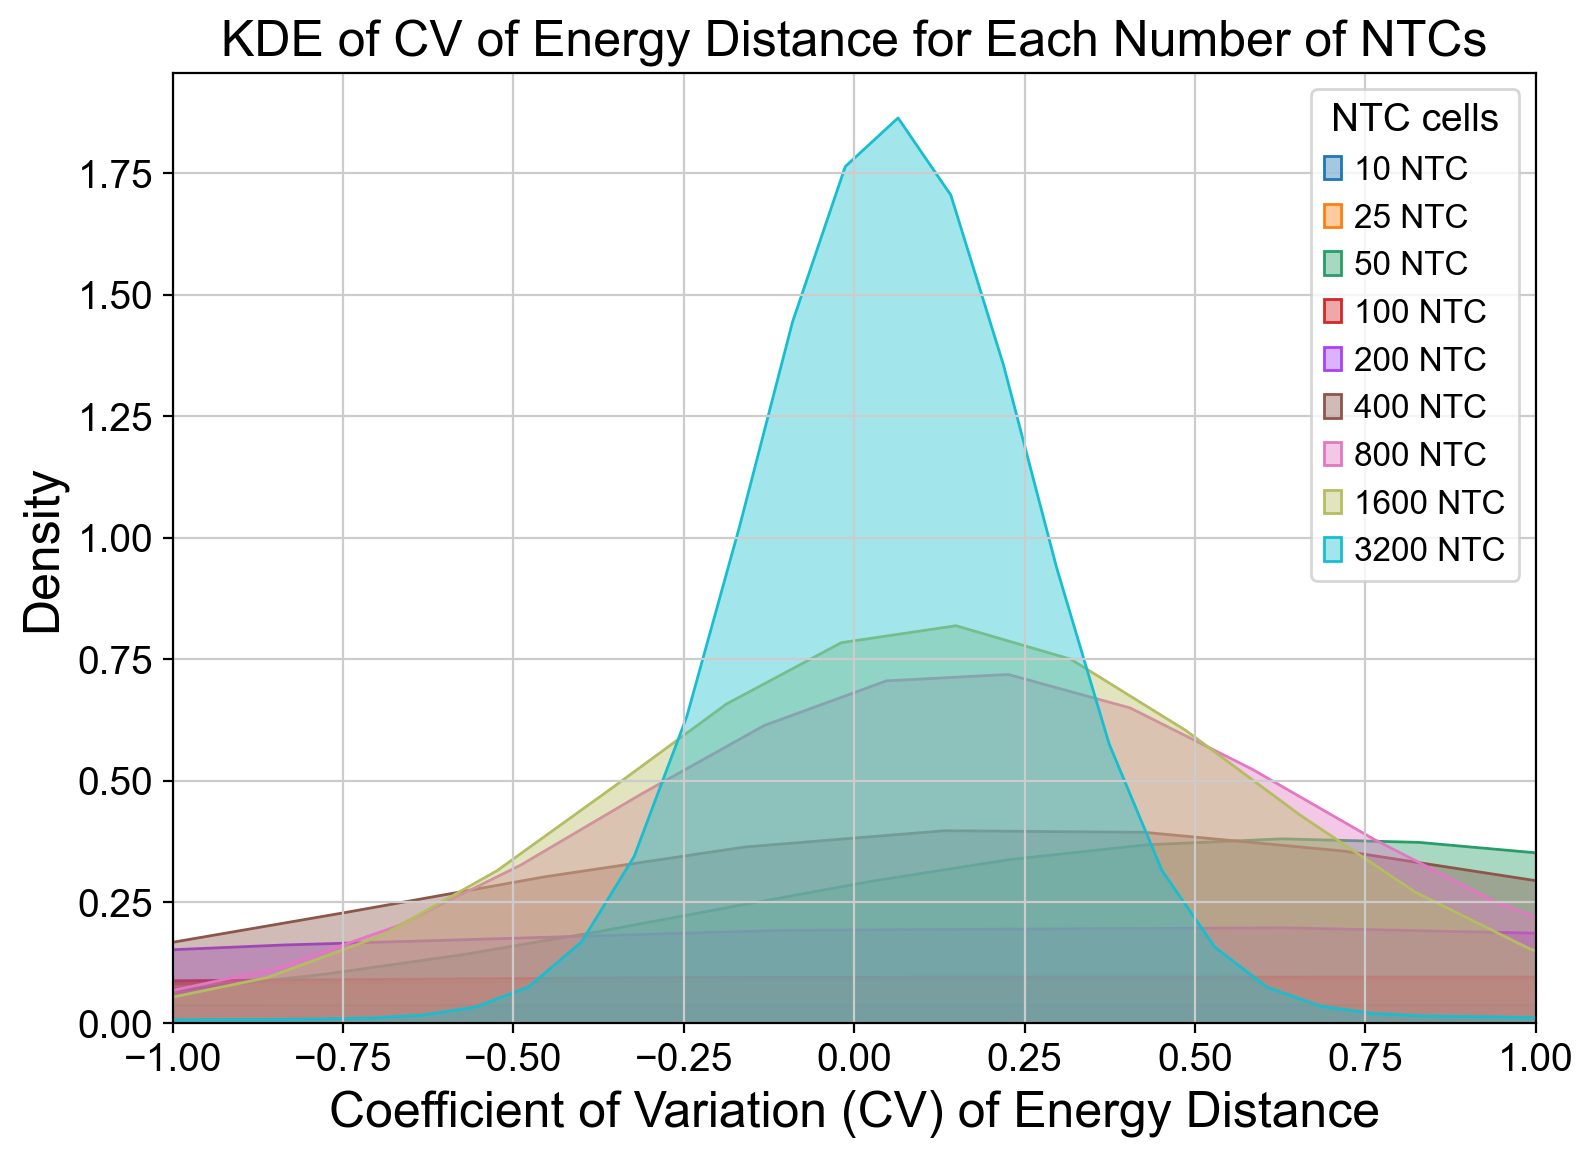

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ntc_counts = edist_results[list(edist_results.keys())[0]]['ntc_counts']
num_ntc = coef_of_variation.shape[1]-1

for i in range(num_ntc):
    sns.kdeplot(
        coef_of_variation[:, i], 
        label=f"{ntc_counts[i]} NTC", 
        fill=True, 
        alpha=0.4
    )

plt.xlabel('Coefficient of Variation (CV) of Energy Distance', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('KDE of CV of Energy Distance for Each Number of NTCs', fontsize=18)
plt.legend(title='NTC cells', fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.xlim(-1,1)
plt.show()

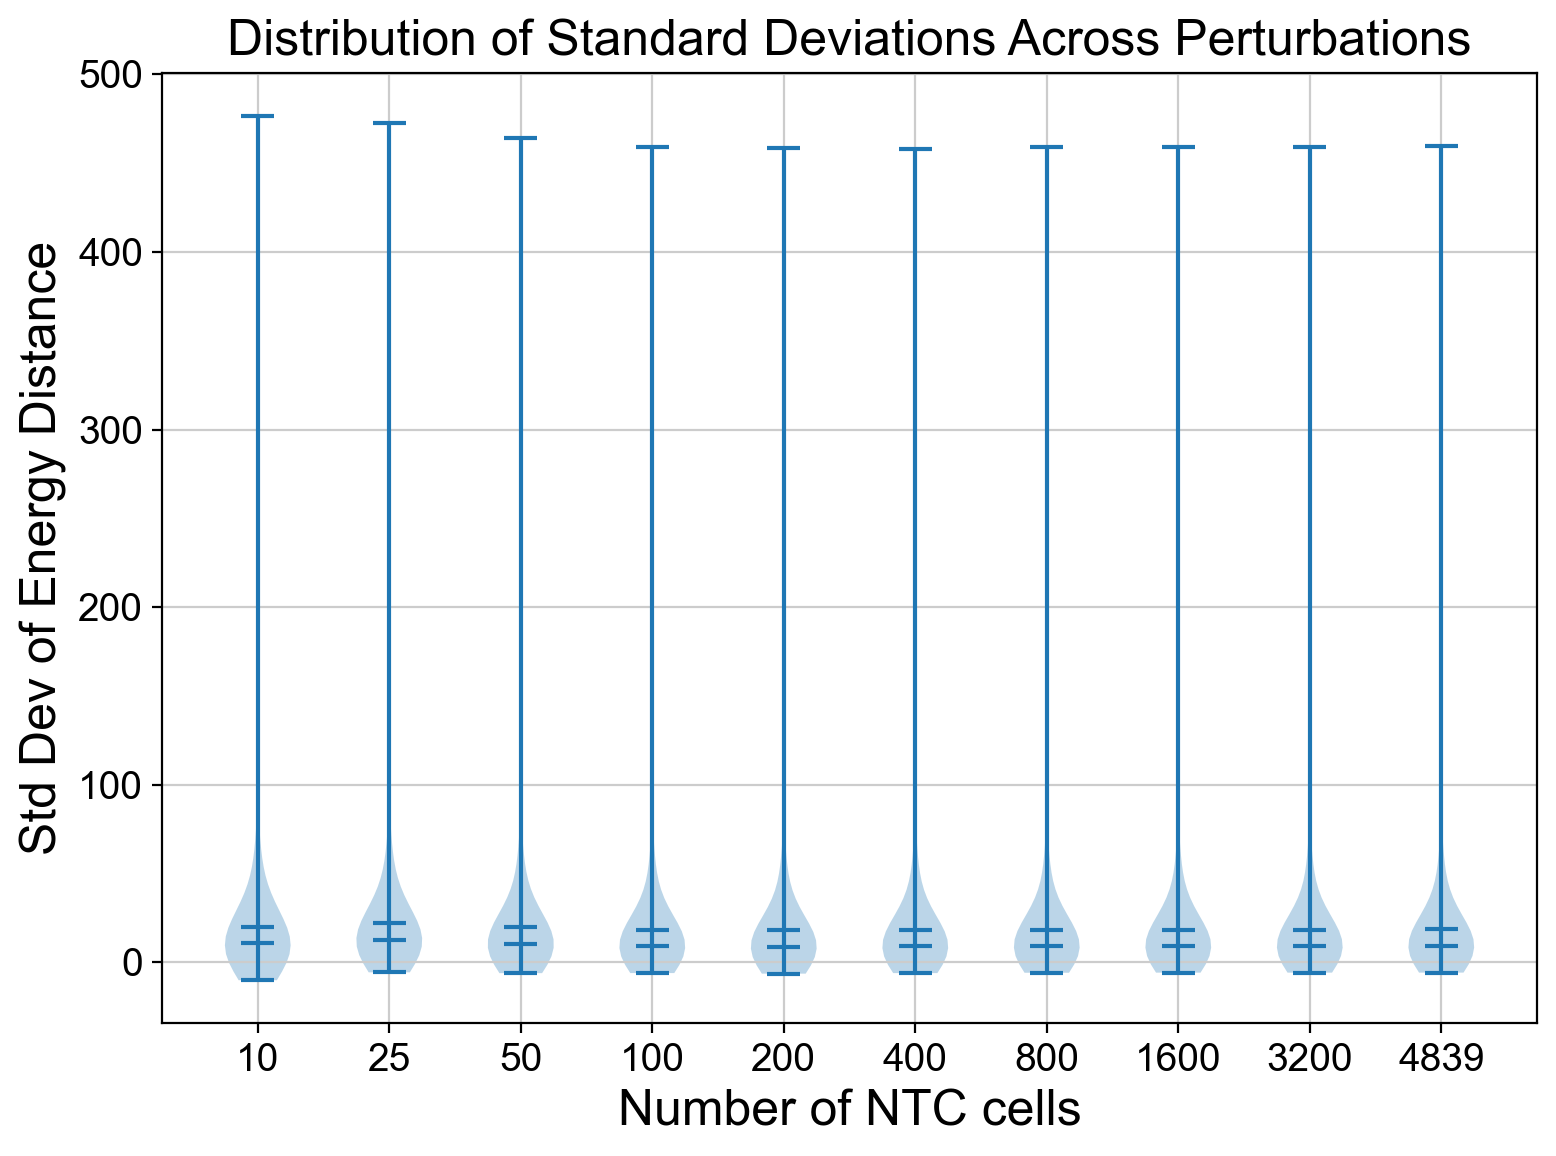

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.violinplot(means, showmeans=True, showmedians=True)
plt.xticks(
    ticks=np.arange(1, means.shape[1] + 1), 
    labels=[str(n) for n in edist_results[list(edist_results.keys())[0]]['ntc_counts']],
    fontsize=14
)
plt.xlabel('Number of NTC cells', fontsize=18)
plt.ylabel('Std Dev of Energy Distance', fontsize=18)
plt.title('Distribution of Standard Deviations Across Perturbations', fontsize=18)
plt.tight_layout()
plt.show()

In [59]:
# Make a plot of the num_ntcs vs mean percent error for all perts at each n_ntc, show mean and SD

# collect all data: for each n_ntc (index), get mean and sd of runtime and mean percent error across all perts
n_ntc_points = len(edist_results[list(edist_results.keys())[0]]['ntc_counts'])  # assumes all have same length
ntc_counts = edist_results[list(edist_results.keys())[0]]['ntc_counts']

mean_runtimes_by_nntc = []
sd_runtimes_by_nntc = []
mean_pct_err_by_nntc = []
sd_pct_err_by_nntc = []

for i in range(n_ntc_points):
    # Collect runtime and percent error for each perturbation at this n_ntc index
    runtimes = []
    pct_errors = []
    for pert in edist_results.keys():
        rt = edist_results[pert]['mean_runtime'][i]
        pe = 100 * (edist_results[pert]['mean'][-1] - edist_results[pert]['mean'][i]) / (edist_results[pert]['mean'][-1] + 1e-6)
        runtimes.append(rt)
        pct_errors.append(abs(pe))
    mean_runtimes_by_nntc.append(np.mean(runtimes))
    sd_runtimes_by_nntc.append(np.std(runtimes))
    mean_pct_err_by_nntc.append(np.mean(pct_errors))
    sd_pct_err_by_nntc.append(np.std(pct_errors))

plt.figure(figsize=(6, 4))
plt.errorbar(ntc_counts, mean_pct_err_by_nntc, 
             xerr=None, yerr=sd_pct_err_by_nntc, 
             fmt='-o', capsize=4, label='Mean ± SD Percent Error')
plt.xlabel('Number of NTC cells', fontsize=16)
plt.xscale('log', base=10)
plt.ylabel('Mean percent error', fontsize=16)
plt.title('Mean percent error vs Number of NTC cells', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

# Optionally, also plot runtime as a separate panel or a secondary y axis if desired.


IndexError: list index out of range

In [53]:
coefs_of_variation = []
for perturbation in edist_results:
    means = edist_results[perturbation]['mean']
    stds = edist_results[perturbation]['std']
    ntc_counts = edist_results[perturbation]['ntc_counts']
    coef_of_variation = abs(np.array(stds) / (1e-6 + np.array(means)))
    coefs_of_variation.append(coef_of_variation)
coefs_of_variation = np.array(coefs_of_variation)

In [57]:
for i in range(coefs_of_variation.shape[1]):
    percent_under_01 = 100 * np.mean(coefs_of_variation[:, i] < 1)
    print(f"Fraction of coefs of variation under 0.1 for NTC index {i}: {percent_under_01:.2f}%")

Fraction of coefs of variation under 0.1 for NTC index 0: 25.68%
Fraction of coefs of variation under 0.1 for NTC index 1: 64.65%
Fraction of coefs of variation under 0.1 for NTC index 2: 69.49%
Fraction of coefs of variation under 0.1 for NTC index 3: 75.23%
Fraction of coefs of variation under 0.1 for NTC index 4: 83.69%
Fraction of coefs of variation under 0.1 for NTC index 5: 89.43%
Fraction of coefs of variation under 0.1 for NTC index 6: 94.26%
Fraction of coefs of variation under 0.1 for NTC index 7: 96.68%
Fraction of coefs of variation under 0.1 for NTC index 8: 97.89%
Fraction of coefs of variation under 0.1 for NTC index 9: 100.00%


(0.0, 5.0)

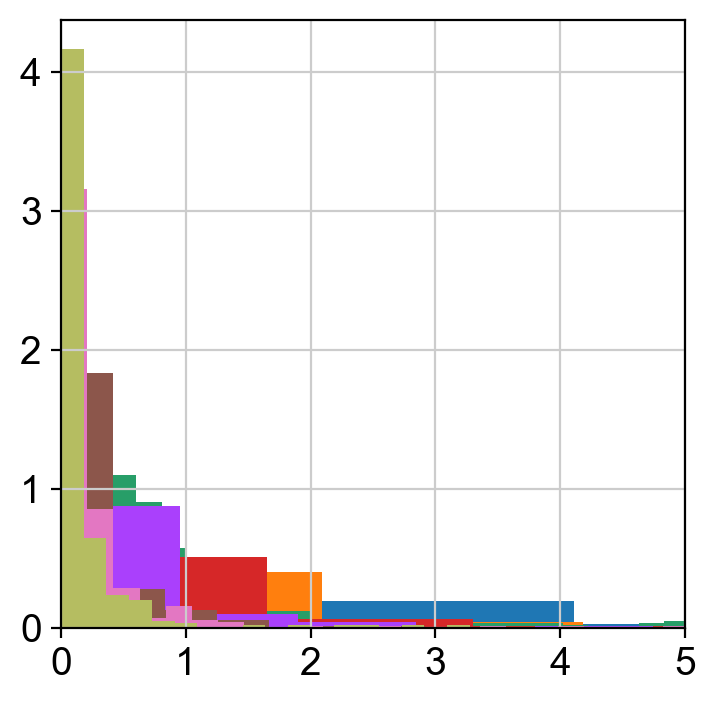

In [54]:
plt.hist(coefs_of_variation[:,0],bins=100,density=True)
plt.hist(coefs_of_variation[:,1],bins=100,density=True)
plt.hist(coefs_of_variation[:,2],bins=100,density=True)
plt.hist(coefs_of_variation[:,3],bins=100,density=True)
plt.hist(coefs_of_variation[:,4],bins=100,density=True)
plt.hist(coefs_of_variation[:,5],bins=100,density=True)
plt.hist(coefs_of_variation[:,6],bins=100,density=True)
plt.hist(coefs_of_variation[:,7],bins=100,density=True)
plt.xlim(0,5)


In [ ]:
from scipy.stats import ks_2samp
res1 = ks_2samp(coefs_of_variation[:,6],coefs_of_variation[:,0])
print(res1)
res2 = ks_2samp(coefs_of_variation[:,6],coefs_of_variation[:,1])
print(res2)
res3 = ks_2samp(coefs_of_variation[:,6],coefs_of_variation[:,2])
print(res3)
res4 = ks_2samp(coefs_of_variation[:,6],coefs_of_variation[:,3])
print(res4)
res5 = ks_2samp(coefs_of_variation[:,6],coefs_of_variation[:,4])
print(res5)
res6 = ks_2samp(coefs_of_variation[:,6],coefs_of_variation[:,5])
print(res6)
res7 = ks_2samp(coefs_of_variation[:,5],coefs_of_variation[:,6])
print(res7)

KstestResult(statistic=0.8126888217522659, pvalue=4.387913474525955e-110, statistic_location=0.49285649605292536, statistic_sign=1)
KstestResult(statistic=0.7129909365558912, pvalue=2.6047948954205834e-81, statistic_location=0.251816144068325, statistic_sign=1)
KstestResult(statistic=0.6918429003021148, pvalue=5.0802181593058835e-76, statistic_location=0.3008344780091419, statistic_sign=1)
KstestResult(statistic=0.6586102719033232, pvalue=3.368338573863507e-68, statistic_location=0.251816144068325, statistic_sign=1)
KstestResult(statistic=0.5196374622356495, pvalue=3.842263755450378e-41, statistic_location=0.24127700787775674, statistic_sign=1)
KstestResult(statistic=0.311178247734139, pvalue=1.4776324193042342e-14, statistic_location=0.15980335093310302, statistic_sign=1)
KstestResult(statistic=0.311178247734139, pvalue=1.4776324193042342e-14, statistic_location=0.15980335093310302, statistic_sign=-1)


(0.0, 5.0)

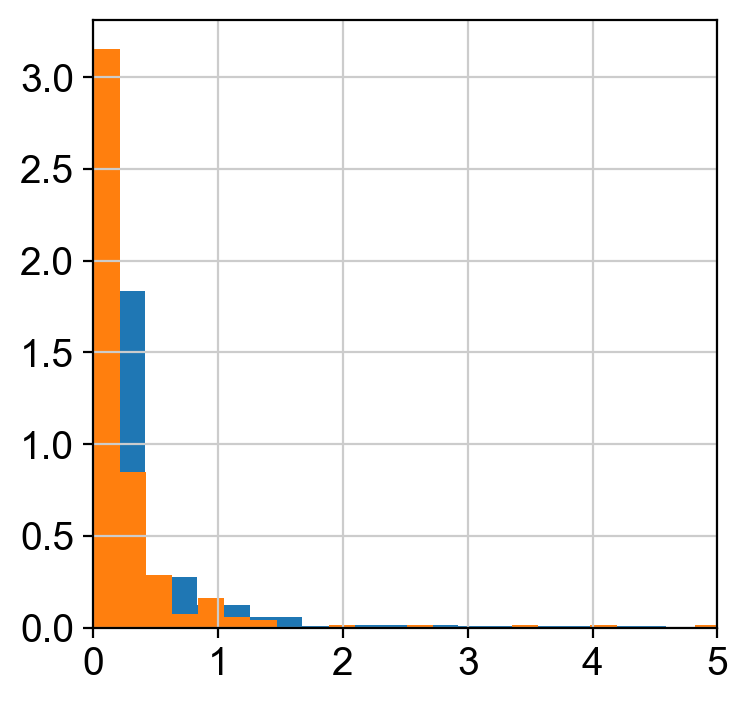

In [ ]:
plt.hist(coefs_of_variation[:,5],bins=100,density=True)
plt.hist(coefs_of_variation[:,6],bins=100,density=True)
plt.xlim(0,5)

In [39]:
percent_error = []
for perturbation in edist_results:
    means = edist_results[perturbation]['mean']
    pct_error = 100*(means[-1]-means)/(means[-1]+1e-6)
    percent_error.append(abs(pct_error))
percent_error = np.array(percent_error)

In [41]:
print(np.mean(percent_error, axis=0))


[113.33102026  72.98437661  35.23272721   6.52868072  11.94289743
   8.57051509   3.13565551   3.15194386   1.96851346   0.        ]


In [17]:
for num_ntcs,i in enumerate(ntc_cell_counts):
    print(num_ntcs,i)
    print(np.mean(percent_error,axis=0)[i])


0 10


IndexError: index 10 is out of bounds for axis 0 with size 10

(0.0, 100.0)

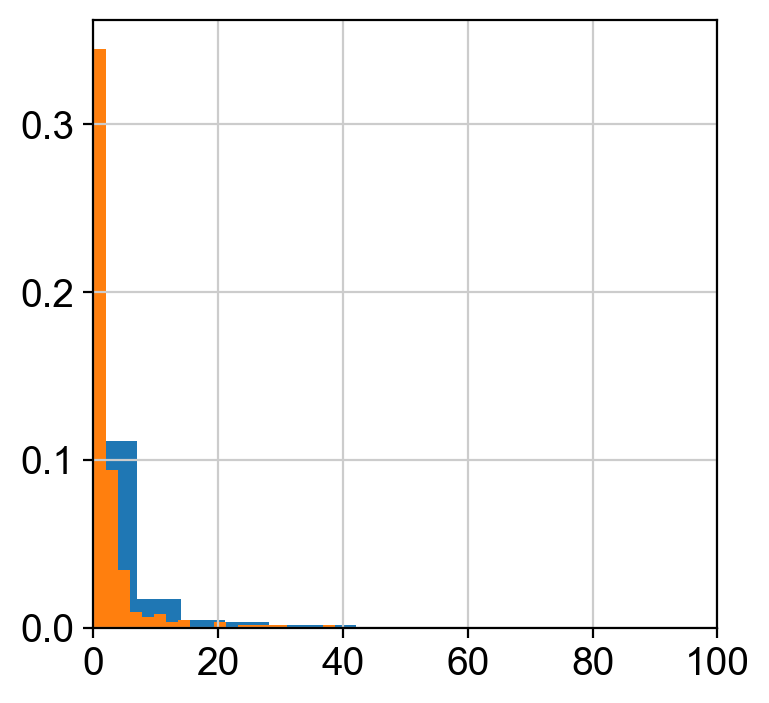

In [12]:
plt.hist(percent_error[:,5],bins=100,density=True)
plt.hist(percent_error[:,6],bins=100,density=True)
plt.xlim(0,100)


In [ ]:
np.mean(coefs_of_variation[:,5])
np.std(coefs_of_variation[:,5])

2.7803557516731323

In [ ]:
np.mean(coefs_of_variation[:,6])
np.std(coefs_of_variation[:,6])

1.4900105973312054

In [8]:
import sys
import os

repo_root = "/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import psp

adata_filepath = "/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/input_files/anndata_objects/KOLF_Pan_Genome_Pre_QC.h5ad"
adata = psp.utils.read_anndata(adata_filepath)

# Subset to cells with NTC sgRNAs that are present in all batches (obs-based)
batch_key = 'batch'
sgRNA_key = 'gRNA' if 'gRNA' in adata.obs_keys() else 'sgRNA'

batches = adata.obs[batch_key].unique()
# All sgRNA names that contain 'NTC'
ntc_grnas = (
    adata.obs.loc[adata.obs[sgRNA_key].astype(str).str.contains('Non-Targeting', na=False), sgRNA_key]
    .astype(str)
    .unique()
)

# Keep only NTC sgRNAs observed in every batch
shared_ntc_grnas = [
    grna for grna in ntc_grnas
    if all(((adata.obs[sgRNA_key] == grna) & (adata.obs[batch_key] == b)).any() for b in batches)
]

# Final subset: only cells for those shared NTC sgRNAs
adata_shared_ntc_sgRNA = adata[adata.obs[sgRNA_key].isin(shared_ntc_grnas)].copy()

res = psp.de.benchmark_NTC_FDR(
    adata_shared_ntc_sgRNA,
    batch_key=batch_key,
    save_path='/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/notebooks/reviews/KOLF_Pan_Genome_NTC_DEG_per_perturbation.csv',
    fig_save_path='/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/notebooks/figs/KOLF_Pan_Genome_NTC_DEG_per_perturbation_unfiltered.svg'
)

2025-11-15 14:01:57 - INFO - Using 108930 non-targeting control cells for benchmarking
2025-11-15 14:01:57 - INFO - Found 472 unique NTC sgRNAs
2025-11-15 14:01:57 - INFO - Performing batch-aware analysis using batch key: batch
2025-11-15 14:01:57 - INFO - Found 3 unique batches


Benchmarking NTC sgRNAs (batch-aware):   0%|          | 0/472 [00:00<?, ?it/s]

/tscc/nfs/home/ydoctor/miniconda3/envs/perturb_seq_env/lib/python3.11/site-packages/pydeseq2/dds.py:807: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
/tscc/nfs/home/ydoctor/miniconda3/envs/perturb_seq_env/lib/python3.11/site-packages/pydeseq2/dds.py:807: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.


KeyboardInterrupt: 

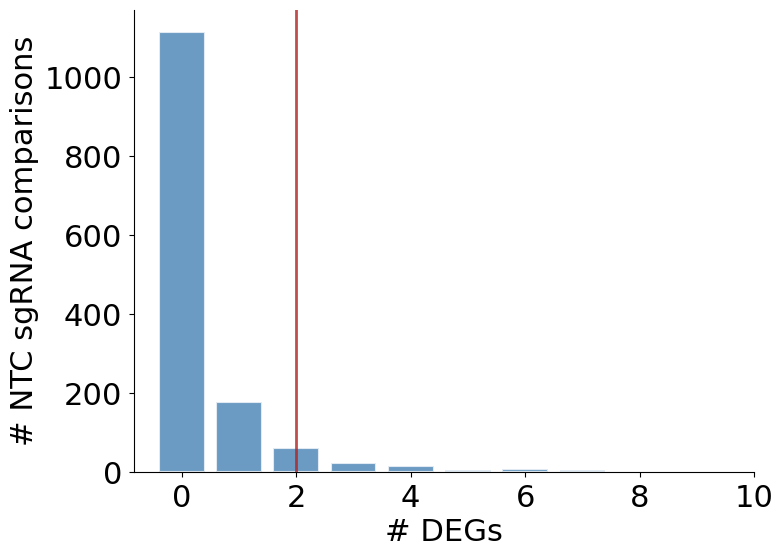

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
benchmark_results = pd.read_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/reviews/KOLF_Pan_Genome_NTC_DEG_per_perturbation.csv')

benchmark_results = benchmark_results.sort_values('n_DEGs', ascending=False)

# Calculate 95th percentile threshold (FDR 0.05)
if len(benchmark_results) > 0:
    deg_threshold = np.percentile(benchmark_results['n_DEGs'].values, 95)


# Plot results with improved aesthetics
# Set style parameters
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Create figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
fig.patch.set_facecolor('white')

# Prepare bar plot data: discrete DEG counts
deg_counts = benchmark_results['n_DEGs'].value_counts().sort_index()

# Create bar plot
ax.bar(
    deg_counts.index,
    deg_counts.values,
    alpha=0.8,
    color='#4682B4',   # Steel blue
    edgecolor='white',
    linewidth=1.5
)

# Add threshold line with improved styling
ax.axvline(
    deg_threshold,
    color='#B22222',  # Firebrick
    linestyle='-',
    linewidth=2,
    alpha=0.8
)

# Labels and title with improved styling
ax.set_xlabel('# DEGs', fontsize=22,)
ax.set_ylabel('# NTC sgRNA comparisons', fontsize=22,)

# Turn off grid
ax.grid(False)

# Adjust tick parameters
ax.tick_params(axis='both', which='major', labelsize=22, pad=5)

# Add some padding to the axes

ax.margins(x=0.01)
plt.xlim(right=10)
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/KOLF_Pan_Genome_NTC_DEG_per_perturbation_reformatted.svg', dpi=300)
